# Task 3 — Heart Disease Classification (Logistic Regression + Decision Tree)

## Goal
- Load `heart.csv`
- Preprocess: train/test split + scaling where appropriate
- Train:
  - Logistic Regression
  - Decision Tree Classifier
- Evaluate:
  - Confusion Matrix
  - Classification Report (Accuracy, Precision, Recall, F1)


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

RANDOM_STATE = 42

def find_heart_csv() -> Path:
    here = Path.cwd()
    candidates = [
        here / "heart.csv",
        here.parent / "heart.csv",
        here.parent.parent / "heart.csv",
    ]
    for p in candidates:
        if p.exists() and p.is_file():
            return p
    raise FileNotFoundError(
        "Could not find heart.csv. Expected in current folder or repository root."
    )

heart_path = find_heart_csv()
df = pd.read_csv(heart_path)
df.shape, str(heart_path)

((1025, 14), '/heart.csv')

## Quick EDA checks

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
display(df.describe(include="all"))
display(df.isna().sum())

if "target" not in df.columns:
    raise ValueError(f"Expected a 'target' column. Found columns: {list(df.columns)}")

display(df["target"].value_counts().rename("target_counts"))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


,target_counts
target,
1,526
0,499


## Train/test split
We stratify by the target to keep class proportions consistent.

In [6]:
X = df.drop(columns=["target"]).copy()
y = df["target"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train.shape, X_test.shape

((820, 13), (205, 13))

## Model 1: Logistic Regression (with scaling)
Logistic Regression is sensitive to feature scale, so we use a `StandardScaler` inside a pipeline.

In [7]:
log_reg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8097560975609757

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



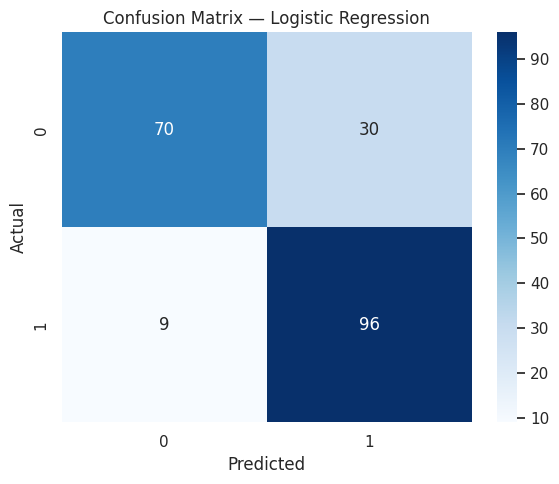

In [8]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Model 2: Decision Tree Classifier
Decision Trees do not require scaling. We train a baseline tree with a fixed random seed.

In [9]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree
Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



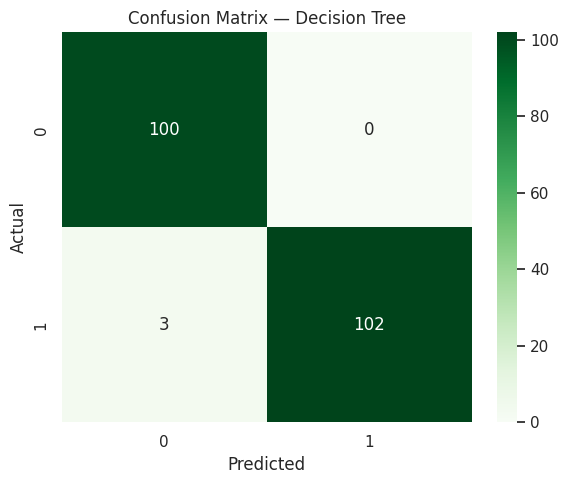

In [10]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Cross-validation (CV)
We estimate generalization performance using **Stratified K-Fold** cross-validation.


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

# Logistic Regression pipeline (scaling + classifier)
log_reg_cv = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

# Decision Tree (no scaling)
tree_cv = DecisionTreeClassifier(random_state=RANDOM_STATE)

cv_lr = cross_validate(log_reg_cv, X, y, cv=cv, scoring=scoring)
cv_tree = cross_validate(tree_cv, X, y, cv=cv, scoring=scoring)

def summarize_cv(name: str, cv_result: dict) -> pd.Series:
    return pd.Series(
        {
            "model": name,
            **{k.replace("test_", ""): float(np.mean(v)) for k, v in cv_result.items() if k.startswith("test_")},
        }
    )

cv_summary = pd.DataFrame(
    [
        summarize_cv("Logistic Regression", cv_lr),
        summarize_cv("Decision Tree", cv_tree),
    ]
).set_index("model")
cv_summary

,accuracy,roc_auc,precision,recall,f1
model,,,,,
Logistic Regression,0.845854,0.920449,0.821702,0.895382,0.856043
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000


## Hyperparameter tuning (GridSearchCV)
We tune key hyperparameters using stratified CV and select by **ROC-AUC**.


In [12]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression grid (use liblinear for small datasets & L1/L2)
log_reg_grid = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid_lr = {
    "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__penalty": ["l1", "l2"],
}

gs_lr = GridSearchCV(
    estimator=log_reg_grid,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
gs_lr.fit(X_train, y_train)

print("Best Logistic Regression params:", gs_lr.best_params_)
print("Best CV ROC-AUC:", gs_lr.best_score_)

# Decision Tree grid
param_grid_tree = {
    "max_depth": [None, 2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
}

gs_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_tree,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
gs_tree.fit(X_train, y_train)

print("\nBest Decision Tree params:", gs_tree.best_params_)
print("Best CV ROC-AUC:", gs_tree.best_score_)

Best Logistic Regression params: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV ROC-AUC: 0.9157600255291991

Best Decision Tree params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV ROC-AUC: 0.9854603676913805


## Evaluate tuned models on the test set
We evaluate the best CV models on the held-out test split.


In [13]:
best_lr = gs_lr.best_estimator_
best_tree = gs_tree.best_estimator_

pred_lr = best_lr.predict(X_test)
pred_tree = best_tree.predict(X_test)

print("Tuned Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("\nClassification Report:\n", classification_report(y_test, pred_lr))

print("\nTuned Decision Tree")
print("Accuracy:", accuracy_score(y_test, pred_tree))
print("\nClassification Report:\n", classification_report(y_test, pred_tree))

Tuned Logistic Regression
Accuracy: 0.8097560975609757

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.69      0.78       100
           1       0.76      0.92      0.83       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205


Tuned Decision Tree
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



## Feature importance
- **Decision Tree**: `feature_importances_`
- **Logistic Regression**: absolute standardized coefficients (after scaling)

,tree_importance
cp,0.230380
ca,0.122085
age,0.118180
chol,0.099915
oldpeak,0.098915
thal,0.093638
trestbps,0.053638
sex,0.051162
restecg,0.049646
thalach,0.043755


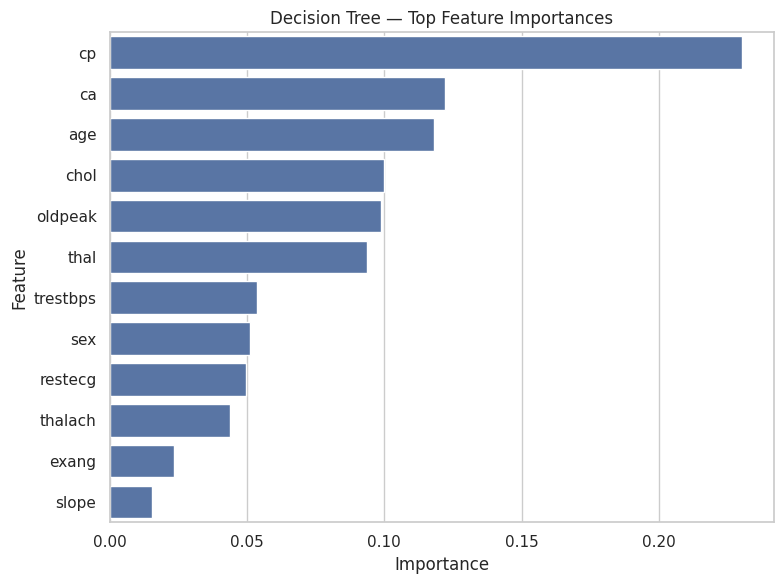

,abs_logreg_coef
cp,0.760947
sex,0.658319
ca,0.651209
oldpeak,0.541140
exang,0.483226
thal,0.457417
thalach,0.376871
slope,0.329394
trestbps,0.308235
chol,0.219286


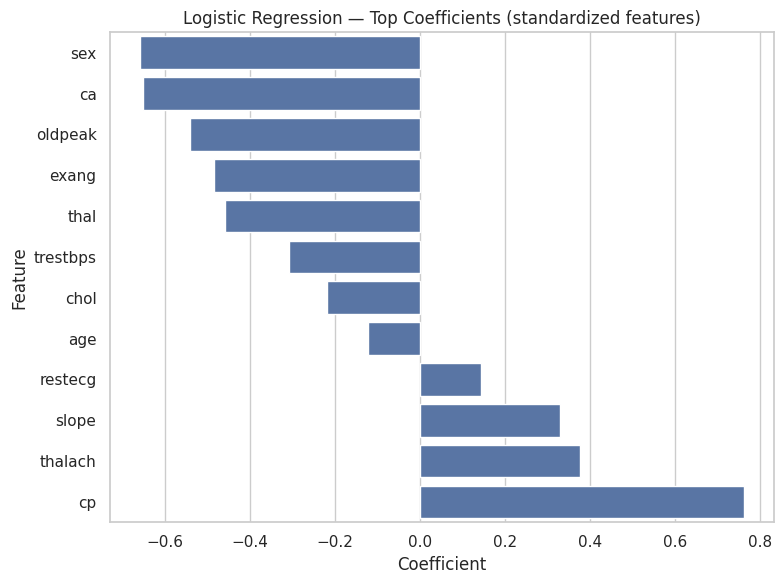

In [14]:
feature_names = list(X.columns)

# Tree feature importances
tree_importances = pd.Series(best_tree.feature_importances_, index=feature_names).sort_values(ascending=False)
display(tree_importances.head(15).to_frame("tree_importance"))

plt.figure(figsize=(8, 6))
sns.barplot(x=tree_importances.values[:12], y=tree_importances.index[:12], orient="h")
plt.title("Decision Tree — Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Logistic Regression coefficients (pipeline: scaler -> model)
lr_model = best_lr.named_steps["model"]
lr_coefs = pd.Series(lr_model.coef_.ravel(), index=feature_names)
lr_rank = lr_coefs.abs().sort_values(ascending=False)
display(lr_rank.head(15).to_frame("abs_logreg_coef"))

plt.figure(figsize=(8, 6))
top_lr = lr_coefs.loc[lr_rank.index[:12]].sort_values()
sns.barplot(x=top_lr.values, y=top_lr.index, orient="h")
plt.title("Logistic Regression — Top Coefficients (standardized features)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## ROC-AUC and ROC curves
We compute ROC-AUC on the test set and plot ROC curves for both tuned models.

Test ROC-AUC (Tuned Logistic Regression): 0.9294
Test ROC-AUC (Tuned Decision Tree):       1.0000


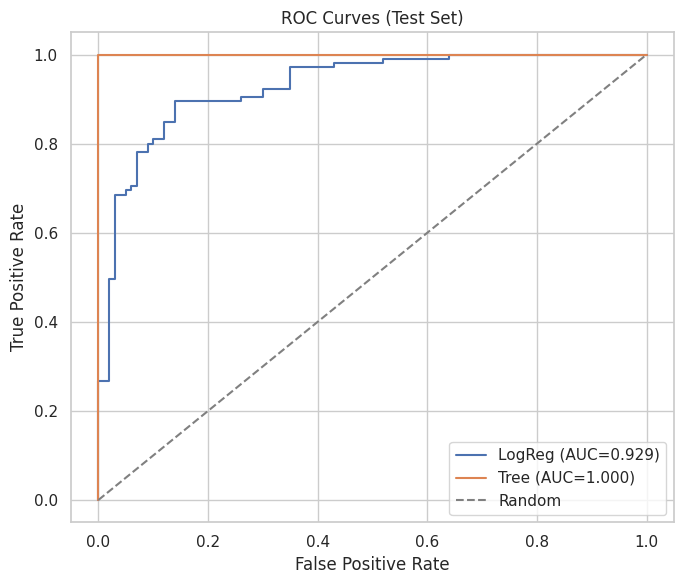

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probabilities for the positive class
proba_lr = best_lr.predict_proba(X_test)[:, 1]
proba_tree = best_tree.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, proba_lr)
auc_tree = roc_auc_score(y_test, proba_tree)

print(f"Test ROC-AUC (Tuned Logistic Regression): {auc_lr:.4f}")
print(f"Test ROC-AUC (Tuned Decision Tree):       {auc_tree:.4f}")

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, proba_tree)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc_lr:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Tree (AUC={auc_tree:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("ROC Curves (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()